In [15]:
# Yoo & Desjacques (2013), Fig.2 left column replication (density + RSD)
# Uses Limber-approximated spherical power spectra for a Gaussian window.

using DelimitedFiles
using Interpolations
using Plots

# ----------------------------
# Cosmology and survey window
# ----------------------------

const h      = 0.7          # Hubble parameter (WMAP7-like)
const Ωm     = 0.27         # matter density parameter
const nbar   = 1e-4         # comoving number density (h^-3 Mpc^3), used in shot noise
const r0     = 2354.0       # comoving distance to z=1, in h^-1 Mpc (as in the paper)
const fgrowth = Ωm^0.55     # linear growth rate f(z=0) ~ Ωm^0.55

"""
    window_gaussian(r; r0=r0)

Gaussian radial window W(r) = exp[-(r/r0)^2] used in Yoo & Desjacques (2013).
r is comoving distance in h^-1 Mpc.
"""
window_gaussian(r; r0=r0) = exp(-(r/r0)^2)

# ----------------------------
# Linear matter power spectrum
# ----------------------------
# You should replace this with real CAMB/CLASS output to match the paper exactly.
# Here we assume a two-column file "Pk_linear_z0.dat" with:
#   k [h/Mpc], P_lin(k) [(Mpc/h)^3]
# or define a simple placeholder if such a file is not available.

function load_Pm_linear(filename::String)
    data = readdlm(filename)
    kdata = data[:,1]
    Pdata = data[:,2]
    # Log-log interpolation is usually safer for P(k)
    itp = LinearInterpolation(log.(kdata), log.(Pdata), extrapolation_bc=Line())
    return k -> exp(itp(log(k)))
end

# Fallback: Eisenstein-Hu-like toy spectrum (not exact WMAP7!)
# This is just a shape; for precise replication, comment this out and use load_Pm_linear.
function toy_Pm_linear(k::Float64)
    # Very rough n_s ~ 0.96 power-law with turnover; purely illustrative.
    k_eq = 0.015     # matter-radiation equality scale in h/Mpc (approx)
    ns   = 0.96
    T    = 1.0 / (1.0 + (k/k_eq)^2)  # crude transfer function
    return (k^(ns)) * (T^2)
end

# Choose which Pm to use:
const use_file_power = false
const Pm = use_file_power ? load_Pm_linear("Pk_linear_z0.dat") : toy_Pm_linear

# ----------------------------
# Spherical power spectra (Limber approximation)
# ----------------------------

"""
    S_density_l(k, l; r0=r0)

Density-only spherical power spectrum S_l^δ(k) ≈ W(ν/k)^2 * P_m(k),
with ν = l + 1/2, and Gaussian window W(r) = exp[-(r/r0)^2].
Implements Eq. (62) in the Limber approximation.
"""
function S_density_l(k::Float64, l::Int; r0=r0)
    ν = l + 0.5
    r = ν / k                    # effective radial distance in Limber approximation
    W = window_gaussian(r; r0=r0)
    return (W^2) * Pm(k)
end

"""
    S_rsd_l(k, l; r0=r0, f=fgrowth)

Linear Kaiser redshift-space distortion spherical power spectrum component.

We model S_l^{RSD}(k) ≈ W(ν/k)^2 * ⟨μ^4⟩ * f^2 * P_m(k),
where ⟨μ^4⟩ = 1/5 is the angular average of μ^4 for an isotropic set of directions.
This follows the plane-parallel 3D result P_z(k, μ) = f^2 μ^4 P_m(k) and
encodes the window dependence as in Eq. (62).
"""
function S_rsd_l(k::Float64, l::Int; r0=r0, f=fgrowth)
    ν = l + 0.5
    r = ν / k
    W = window_gaussian(r; r0=r0)
    μ4_avg = 1.0 / 5.0
    return (W^2) * (μ4_avg * f^2) * Pm(k)
end

"""
    N_shot_l(k, l; r0=r0, nbar=nbar)

Shot-noise spherical power spectrum N_l(k) ≈ nbar^{-1} * W(ν/k),
from Eq. (28) in Limber approximation.
"""
function N_shot_l(k::Float64, l::Int; r0=r0, nbar=nbar)
    ν = l + 0.5
    r = ν / k
    W = window_gaussian(r; r0=r0)
    return W / nbar
end

# ----------------------------
# Plotting the left column of Fig. 2
# ----------------------------

"""
    plot_left_column(; ls = [2,4,6,8,10], kmin=1e-3, kmax=1.0, nk=200)

Reproduce the qualitative structure of Fig. 2 (left column) in Yoo & Desjacques (2013):
- Solid: density spherical power S_l^δ(k)
- Dashed: RSD spherical power S_l^{RSD}(k)
- Dotted: shot-noise N_l(k)
- Gray solid: 3D matter power spectrum P_m(k)
Each l is plotted in its own panel, with a vertical line at k_c = l / r0.
"""
function plot_left_column(; ls = [2,4,6,8,10], kmin=1e-3, kmax=1.0, nk=300)
    ks = exp.(range(log(kmin), log(kmax), length=nk))
    nL = length(ls)

    plt = plot(layout = (nL, 1), size=(700, 1200))

    for (i, l) in enumerate(ls)
        Sd = [S_density_l(k, l) for k in ks]
        Sz = [S_rsd_l(k, l)     for k in ks]
        Nn = [N_shot_l(k, l)    for k in ks]
        P3 = [Pm(k)             for k in ks]

        k_c = l / r0

        p = plot(ks, Sd,  lw=2,  color=:blue,  label="density S_l^δ(k)")
        plot!(ks, Sz,    lw=2,  color=:red,   ls=:dash,  label="RSD S_l^{RSD}(k)")
        plot!(ks, Nn,    lw=2,  color=:black, ls=:dot,   label="shot noise N_l(k)")
        plot!(ks, P3,    lw=2,  color=:gray,  ls=:solid, label="3D P_m(k)")

        # vertical line at k_c = l / r0
        vline!(p, [k_c], lw=1, color=:green, ls=:dash, label="k_c = l / r0")

        xlabel!(p, "k [h Mpc⁻¹]")
        ylabel!(p, "Power (arb. units)")
        title!(p, "l = $l")
        #xscale!(p, :log10)
        #yscale!(p, :log10)

        plot!(plt, p, subplot=i)
    end

    display(plt)
end



plot_left_column

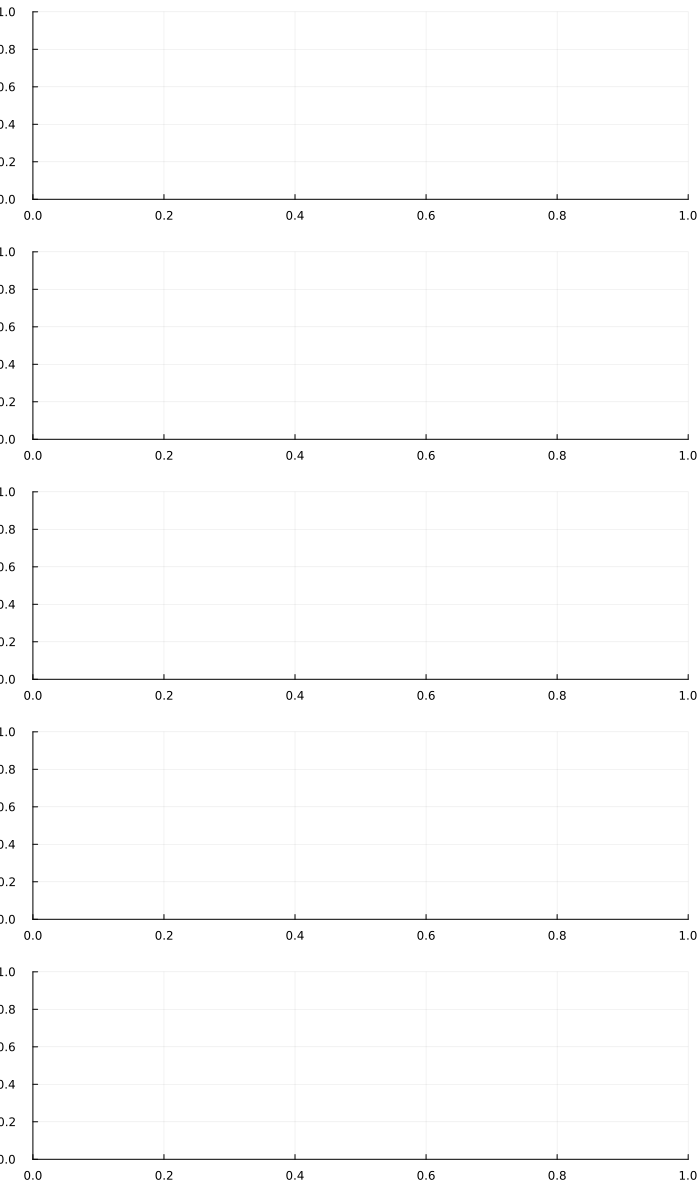

In [16]:
# Call the plotting function:
plot_left_column()